### PyTorch DataLoader Exercises

Welcome to the PyTorchDataLoader exercise template notebook.

There are several questions in this notebook and it's your goal to answer them by writing Python and PyTorch code.

> **Note:** There may be more than one solution to each of the exercises, don't worry too much about the *exact* right answer. Try to write some code that works first and then improve it if you can.



In [55]:
# Import necessary libraries
import os
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import requests
from zipfile import ZipFile
from io import BytesIO
import numpy as np


Download the dataset (not our case)

In [56]:

# Define the path to the dataset
#dataset_path = 'lab01/DATA-tiny-imagenet-200'  # Replace with the path to your dataset

# Send a GET request to the URL
#response = requests.get(dataset_path)
# Check if the request was successful
#if response.status_code == 200:
#    # Open the downloaded bytes and extract them
#    with ZipFile(BytesIO(response.content)) as zip_file:
#        zip_file.extractall('/dataset')
#    print('Download and extraction complete!')


In [57]:
import os
os.listdir()

['jupyter_env', 'datasets']

In [58]:
torch.manual_seed(0)
np.random.seed(0)

# Define transformations for the dataset
data_transforms = {
    'train': transforms.Compose([
        #transforms.Resize(),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ]),
    'test': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    ])
}

dataset_path = 'datasets/tiny-imagenet-200'  # Replace with the path to your dataset

# Load the dataset
tiny_imagenet_dataset_train = ImageFolder(root=dataset_path + '/train', transform=data_transforms['train'])
tiny_imagenet_dataset_test = ImageFolder(root=dataset_path + '/test', transform=data_transforms['test'])

# Create a DataLoader
dataloader_train = DataLoader(tiny_imagenet_dataset_train, batch_size=32, shuffle=True, num_workers=4)
dataloader_test = DataLoader(tiny_imagenet_dataset_test, batch_size=32, shuffle=True) # It's a good idea test with the maximum possible?

# Determine the number of classes and samples
num_classes = len(tiny_imagenet_dataset_train.classes)
num_samples = len(tiny_imagenet_dataset_train)

print(f'Number of classes: {num_classes}')
print(f'Number of samples: {num_samples}')



Number of classes: 200
Number of samples: 100000


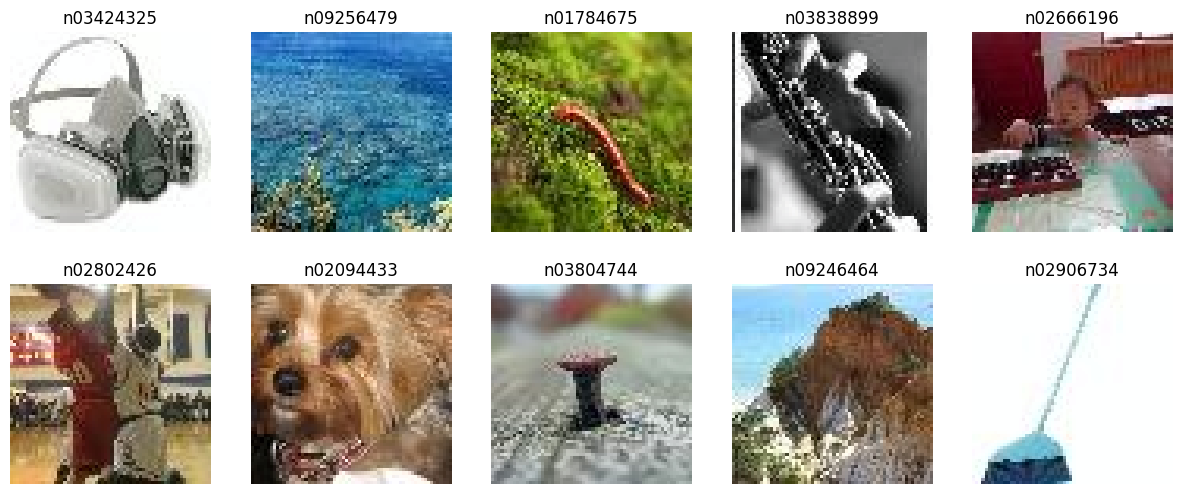

In [61]:

# Function to denormalize image for visualization
def denormalize(image):
    image = image.to('cpu').numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = image * std + mean
    image = np.clip(image, 0, 1)
    return image

# Visualize one example for each class for 10 classes
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
classes_sampled = []
found_classes = 0

# Iterate over the dataloader
for i, (inputs, classes) in enumerate(dataloader_train):
    # Flatten the axes array for easy indexing
    axes = axes.flatten()

    # Iterate over the images of the batch and their corresponding classes
    for img, cls in zip(inputs, classes):
        # Check if the class has already been sampled
        if cls not in classes_sampled:
            # Denormalize the image and display it on the corresponding axis
            axes[found_classes].imshow(denormalize(img))
            # Set the title of the axis to the class name
            axes[found_classes].set_title(tiny_imagenet_dataset_train.classes[cls])
            # Remove the axis ticks
            axes[found_classes].axis('off')
            # Add the class to the list of sampled classes
            classes_sampled.append(cls)
            # Increment the count of found classes
            found_classes += 1
        # Break the loop if 10 classes have been found
        if found_classes >= 10: break
    # Break the loop if 10 classes have been found
    if found_classes >= 10: break

plt.show()